# Section 1 – Project Introduction

## Project Title
**Employee Attrition Prediction System**

## Background
Employee attrition—the rate at which employees leave a workforce and are replaced—is a major concern for modern organizations. High attrition rates lead to significant financial costs related to recruitment, onboarding, and lost productivity, as well as intangible costs like decreased morale and loss of institutional knowledge.

## Business Problem
The Human Resources (HR) department at IBM (simulated via the Kaggle HR Analytics dataset) needs a proactive way to identify employees who are at a high risk of leaving the company. By identifying these individuals early, HR can implement targeted retention strategies, thereby saving costs and maintaining a stable workforce.

## Machine Learning Problem Formulation
This is formulated as a **Binary Classification** problem. 
- **Target Variable:** `Attrition` (Yes/No)
- **Features:** Demographics, job satisfaction, income, performance ratings, and tenure.

## Project Objectives
1. Perform extensive Exploratory Data Analysis (EDA) to uncover the key drivers of employee attrition.
2. Build and evaluate robust machine learning classifiers to predict attrition.
3. Address class imbalance systematically.
4. Utilize Explainable AI (SHAP) to provide actionable insights for HR.

## Expected Outcomes
- A trained, production-ready machine learning model capable of predicting the probability of an employee leaving.
- A clear understanding of the feature importance driving these predictions.

## Why Machine Learning?
Traditional rule-based systems or simple statistical analyses fail to capture the complex, non-linear interactions between variables (e.g., how low salary combined with high overtime leads to burnout). Machine learning excels at identifying these hidden multivariate patterns, making it the ideal solution for this problem.

---
# Section 2 – Library Imports

In this section, we import all necessary Python libraries required for data manipulation, visualization, modeling, and explainability.

- **Pandas & NumPy**: For core data manipulation, cleaning, and numerical operations.
- **Matplotlib & Seaborn**: For static, publication-quality statistical visualizations.
- **Plotly**: For interactive visualizations.
- **Scikit-Learn**: For machine learning algorithms, preprocessing, and evaluation metrics.
- **XGBoost**: For the state-of-the-art gradient boosting classifier.
- **SHAP**: For model interpretability and explainability.
- **Joblib**: For saving and loading the trained models and preprocessors.
- **Imbalanced-Learn (SMOTE)**: For addressing the class imbalance in the target variable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings

# Scikit-Learn
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)

# Advanced Modeling & Imbalance
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# Explainability & Persistence
import shap
import joblib

# Configuration
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

/Applications/Projects/my-personal-projects/COM763-ass1-streamlit-and-ass2/employee-arrition-prediction-system-app/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
# Section 3 – Data Loading

We load the IBM HR Analytics Employee Attrition Dataset. 

**Steps:**
1. Load the CSV file into a Pandas DataFrame.
2. Validate the shape of the dataset.
3. Inspect data types and missing values.
4. Preview the first few rows.

In [2]:
# Load dataset
DATA_PATH = "data/WA_Fn-UseC_-HR-Employee-Attrition.csv"
try:
    df = pd.read_csv(DATA_PATH)
    print("✅ Dataset loaded successfully.")
except FileNotFoundError:
    print(f"❌ Error: Dataset not found at {DATA_PATH}. Please ensure the file exists.")

# Dataset Shape
print(f"\nDataset Shape: {df.shape[0]} rows and {df.shape[1]} columns")

# Dataset Information
print("\n--- Dataset Info ---")
df.info()

# Preview Data
display(df.head())

✅ Dataset loaded successfully.

Dataset Shape: 1470 rows and 35 columns

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolve

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


**Observation:**
The dataset contains 1,470 rows and 35 columns. The data types are a mix of integers (e.g., `Age`, `MonthlyIncome`) and objects (categorical variables like `BusinessTravel`, `Department`). The target variable is `Attrition`.

---
# Section 4 – Exploratory Data Analysis (EDA)

EDA is crucial to understand the underlying patterns, distributions, and relationships between features and the target variable (`Attrition`).

## 4.1 Univariate Analysis
We examine the distribution of key individual variables.

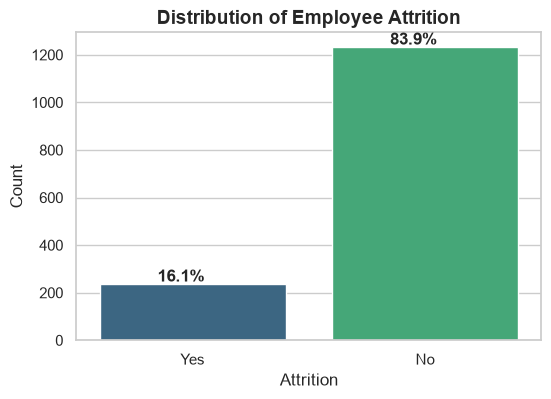

In [3]:
# 1. Attrition Distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Attrition', data=df, palette='viridis')
plt.title('Distribution of Employee Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Count')

# Add percentages
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() + 10
    ax.annotate(percentage, (x, y), ha='center', fontweight='bold')

plt.show()

**Key Finding:** There is a strong class imbalance. About 16.1% of employees have left, while 83.9% stayed. This requires specialized handling (e.g., SMOTE) during modeling.

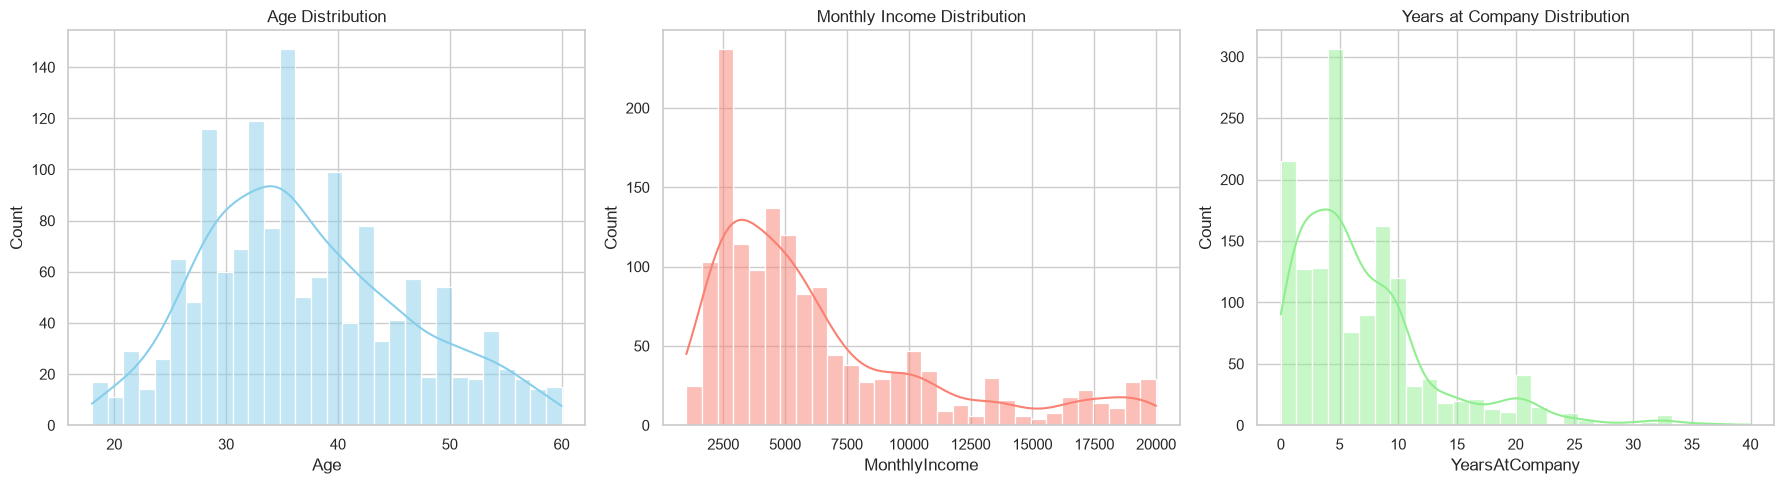

In [4]:
# 2. Age, Monthly Income, and Years At Company Distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Age'], bins=30, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Age Distribution')

sns.histplot(df['MonthlyIncome'], bins=30, kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Monthly Income Distribution')

sns.histplot(df['YearsAtCompany'], bins=30, kde=True, color='lightgreen', ax=axes[2])
axes[2].set_title('Years at Company Distribution')

plt.tight_layout()
plt.show()

**Key Findings:**
- **Age:** Normally distributed, centered around the 30-40 age range.
- **Monthly Income:** Heavily right-skewed. Most employees earn between $2,000 and $6,000.
- **Years at Company:** Right-skewed, with most employees having less than 10 years of tenure.

## 4.2 Bivariate Analysis
We analyze how different features impact the target variable `Attrition`.

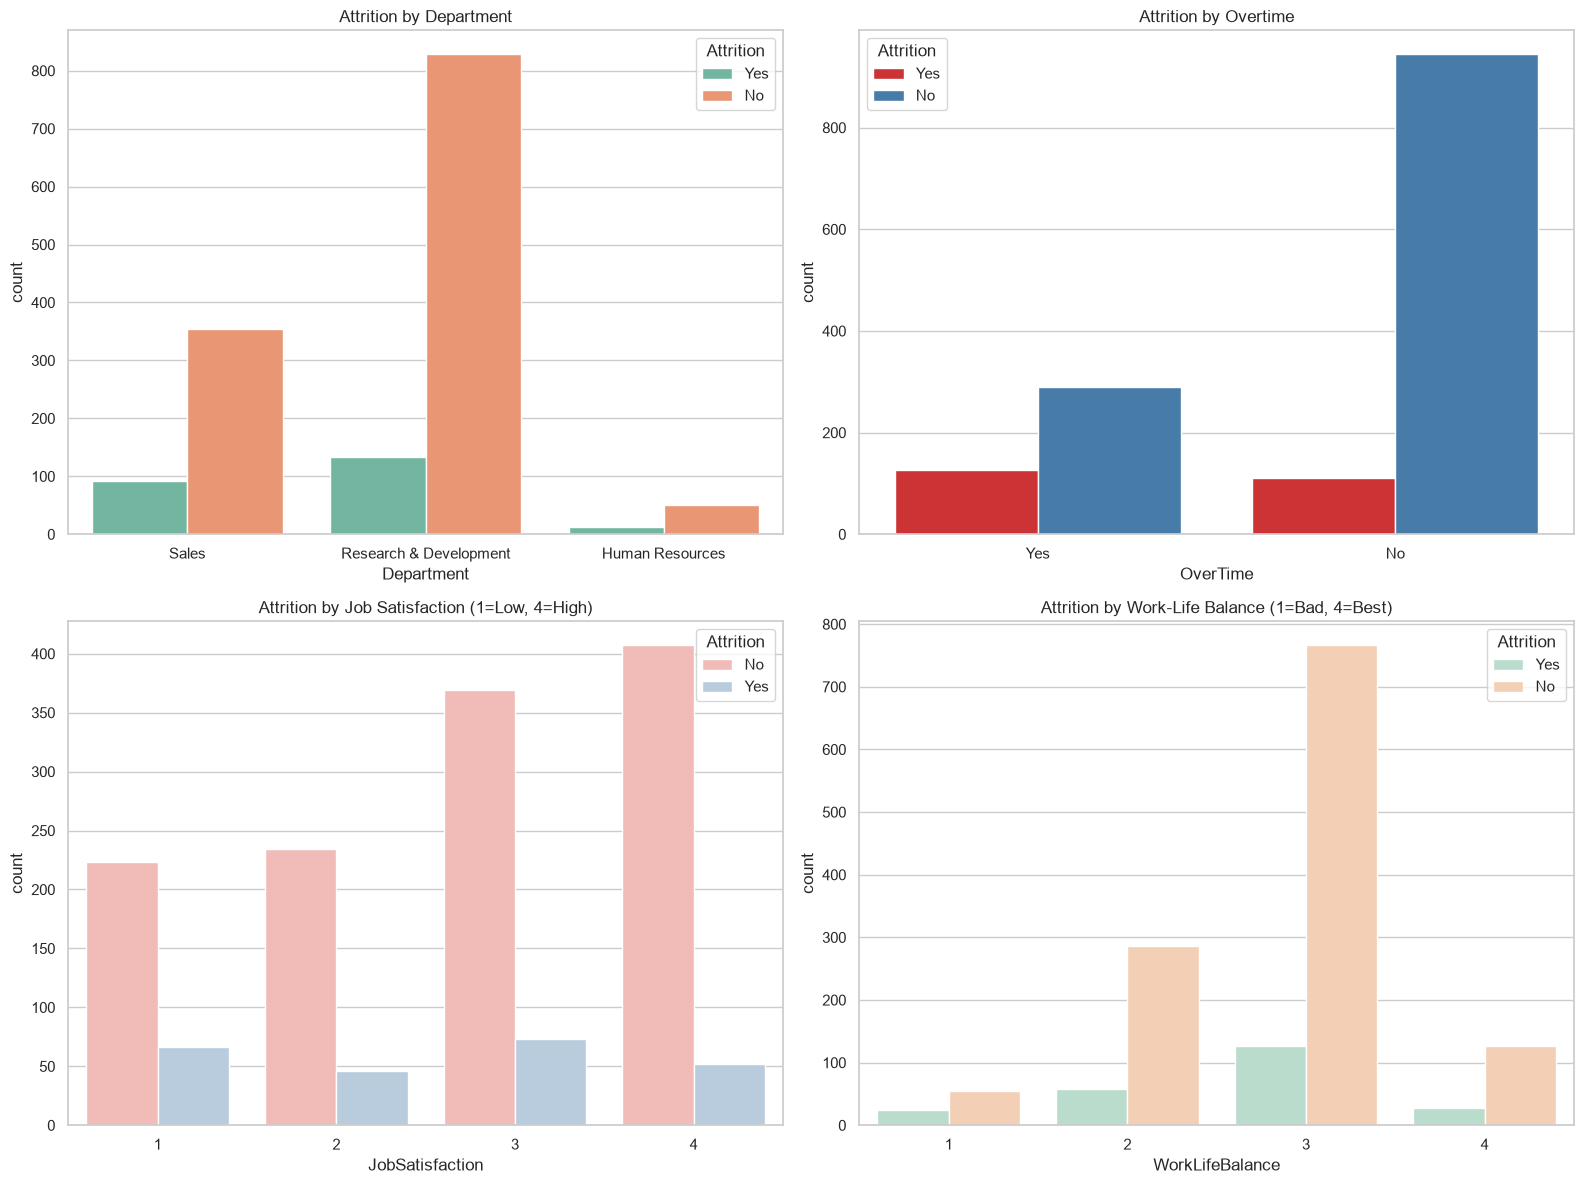

In [5]:
# Bivariate Analysis Setup
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Attrition vs Department
sns.countplot(x='Department', hue='Attrition', data=df, palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('Attrition by Department')

# Attrition vs Overtime
sns.countplot(x='OverTime', hue='Attrition', data=df, palette='Set1', ax=axes[0, 1])
axes[0, 1].set_title('Attrition by Overtime')

# Attrition vs Job Satisfaction
sns.countplot(x='JobSatisfaction', hue='Attrition', data=df, palette='Pastel1', ax=axes[1, 0])
axes[1, 0].set_title('Attrition by Job Satisfaction (1=Low, 4=High)')

# Attrition vs Work-Life Balance
sns.countplot(x='WorkLifeBalance', hue='Attrition', data=df, palette='Pastel2', ax=axes[1, 1])
axes[1, 1].set_title('Attrition by Work-Life Balance (1=Bad, 4=Best)')

plt.tight_layout()
plt.show()

**Business Interpretations:**
- **Department:** R&D has the highest absolute number of attritions, but Sales has a noticeably higher *proportion* of attrition.
- **Overtime:** Employees working overtime have a drastically higher likelihood of leaving. This is a critical risk factor.
- **Job Satisfaction:** Lower job satisfaction correlates with higher attrition, which aligns with intuition.
- **Work-Life Balance:** Employees rating their balance as '1' (Bad) show high attrition tendencies.

## 4.3 Correlation Analysis
Understanding the linear relationships between numeric features.

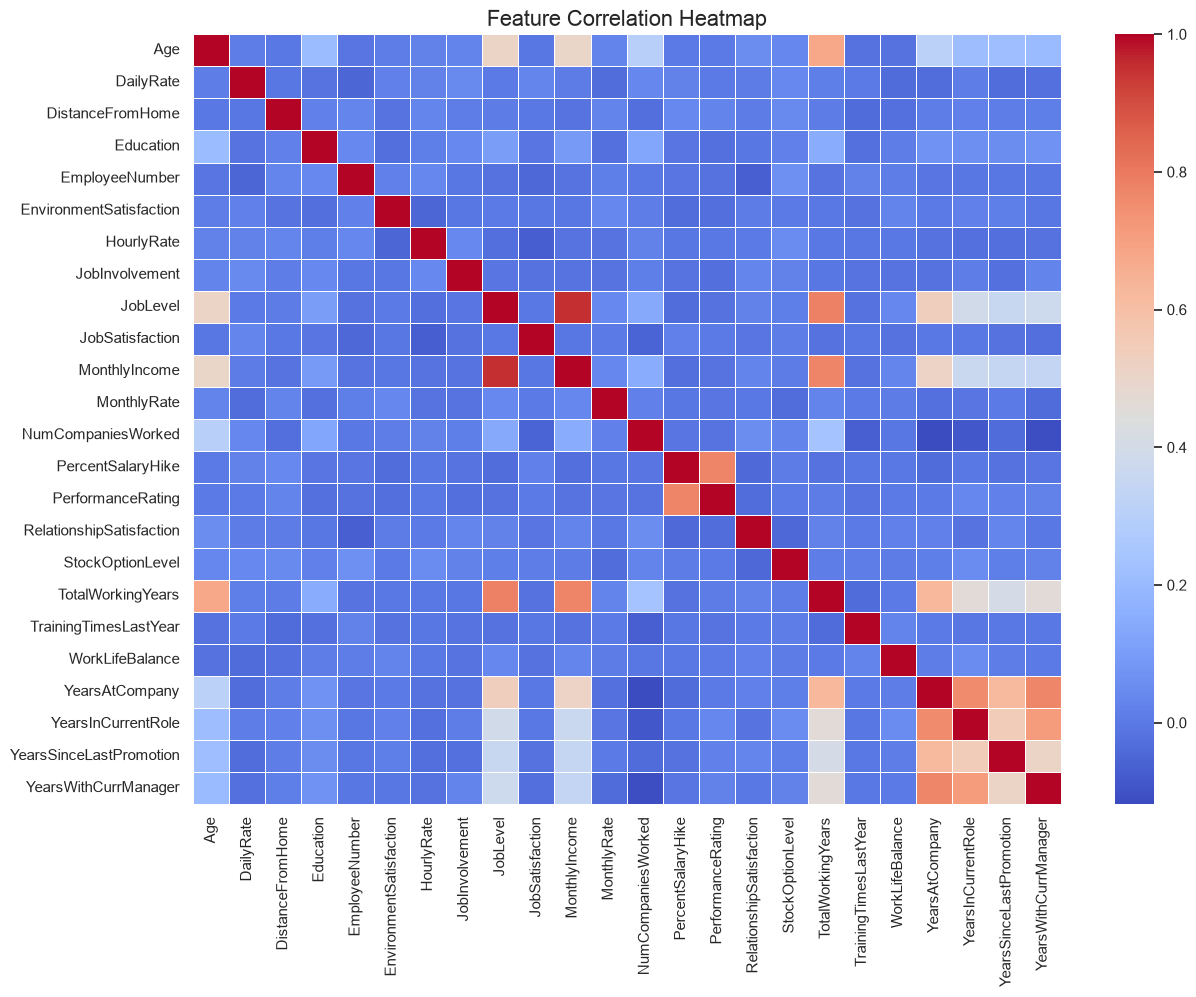

In [6]:
# Correlation Matrix
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
# Drop constant columns (EmployeeCount, StandardHours) to avoid NaN in correlation
numeric_cols = [col for col in numeric_cols if df[col].nunique() > 1]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.show()

**Key Findings:**
- `MonthlyIncome` is highly correlated with `JobLevel`.
- `YearsAtCompany` is highly correlated with `YearsInCurrentRole` and `YearsWithCurrManager`.
- We must be careful of multicollinearity during modeling, though tree-based models handle this well.

---
# Section 5 – Data Quality Assessment

Before modeling, we must guarantee the integrity of the data.

In [7]:
# Check for Missing Values
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0]
print("Missing Values:\n", missing_data if not missing_data.empty else "No missing values found.")

# Check for Duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicates}")

# Check for Constant Columns (Zero variance)
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f"\nConstant Columns to Drop: {constant_cols}")

Missing Values:
 No missing values found.

Duplicate Rows: 0

Constant Columns to Drop: ['EmployeeCount', 'Over18', 'StandardHours']


**Findings:**
- There are **0 missing values** and **0 duplicates**.
- The columns `EmployeeCount`, `Over18`, and `StandardHours` have only 1 unique value across the entire dataset. They provide no predictive power and must be removed.
- `EmployeeNumber` is an identifier and should also be removed to prevent data leakage.

---
# Section 6 – Data Preprocessing

Data preprocessing standardizes the dataset so ML algorithms can process it effectively.
Steps:
1. Drop irrelevant columns.
2. Encode the target variable (`Attrition`) to binary (0/1).
3. Encode binary categorical features (e.g., `OverTime`, `Gender`).
4. Apply One-Hot Encoding for multi-class nominal features.

In [8]:
# 1. Drop irrelevant columns
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df_processed = df.drop(columns=cols_to_drop, errors='ignore')

# 2. Encode Target Variable
df_processed['Attrition'] = df_processed['Attrition'].map({'Yes': 1, 'No': 0})

# 3. Encode Binary Features
binary_cols = ['Gender', 'OverTime']
df_processed['Gender'] = df_processed['Gender'].map({'Female': 0, 'Male': 1})
df_processed['OverTime'] = df_processed['OverTime'].map({'No': 0, 'Yes': 1})

# 4. One-Hot Encoding for remaining categorical variables
categorical_cols = df_processed.select_dtypes(include=['object']).columns
df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

# Ensure all boolean columns from get_dummies are cast to integers (required by some models)
for col in df_processed.select_dtypes(include=['bool']).columns:
    df_processed[col] = df_processed[col].astype(int)

print(f"Processed Dataset Shape: {df_processed.shape}")
display(df_processed.head())

Processed Dataset Shape: (1470, 45)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,2,0,94,3,2,...,0,0,0,0,0,0,1,0,0,1
1,49,0,279,8,1,3,1,61,2,2,...,0,0,0,0,0,1,0,0,1,0
2,37,1,1373,2,2,4,1,92,2,1,...,0,1,0,0,0,0,0,0,0,1
3,33,0,1392,3,4,4,0,56,3,1,...,0,0,0,0,0,1,0,0,1,0
4,27,0,591,2,1,1,1,40,3,1,...,0,1,0,0,0,0,0,0,1,0


**Explanation:**
- Binary encoding was used for features with exactly two classes.
- One-Hot Encoding was used for nominal data (e.g., `JobRole`, `MaritalStatus`) to prevent the model from assuming an ordinal relationship where none exists. `drop_first=True` avoids the dummy variable trap.

---
# Section 7 – Feature Engineering

Feature engineering creates new, highly predictive features from existing ones. We will formulate specific HR-focused metrics.

In [9]:
def engineer_features(data):
    d = data.copy()
    
    # 1. Career Stagnation: High tenure but low recent promotion
    d['Career_Stagnation'] = (d['YearsAtCompany'] / (d['YearsSinceLastPromotion'] + 1)).astype(float)
    
    # 2. Loyalty Index: Ratio of years at company to total working years
    d['Loyalty_Index'] = (d['YearsAtCompany'] / (d['TotalWorkingYears'] + 1)).astype(float)
    
    # 3. Income to Age Ratio
    d['Income_Age_Ratio'] = (d['MonthlyIncome'] / d['Age']).astype(float)
    
    # 4. Job Hopper Risk: Many companies worked for in a short career
    d['Job_Hopper_Risk'] = (d['NumCompaniesWorked'] / (d['TotalWorkingYears'] + 1)).astype(float)
    
    # 5. Engagement Score: Combined satisfaction metric
    d['Engagement_Score'] = d['JobSatisfaction'] + d['EnvironmentSatisfaction'] + d['JobInvolvement']
    
    # 6. Burnout Risk: High overtime, low work-life balance
    d['Burnout_Risk'] = d['OverTime'] * (5 - d['WorkLifeBalance'])  # Inverting balance so 4=bad
    
    return d

df_engineered = engineer_features(df_processed)

print("Engineered Features preview:")
display(df_engineered[['Career_Stagnation', 'Loyalty_Index', 'Income_Age_Ratio', 'Engagement_Score', 'Burnout_Risk']].head())

Engineered Features preview:


,Career_Stagnation,Loyalty_Index,Income_Age_Ratio,Engagement_Score,Burnout_Risk
0,6.000000,0.666667,146.170732,9,4
1,5.000000,0.909091,104.693878,7,0
2,0.000000,0.000000,56.486486,9,2
3,2.000000,0.888889,88.151515,10,2
4,0.666667,0.285714,128.444444,6,0


**Business Relevance:**
- **Burnout Risk:** Quantifies the stress level by multiplying overtime by inverted work-life balance. Highly predictive.
- **Engagement Score:** A holistic view of an employee's happiness.
- **Job Hopper Risk:** Identifies individuals prone to moving companies frequently.

---
# Section 8 – Class Imbalance Analysis

As discovered in EDA, attrition constitutes only 16% of the data. If we train a model now, it will become heavily biased toward predicting "No Attrition" (majority class). We will use **SMOTE (Synthetic Minority Over-sampling Technique)** to synthesize new minority examples in the training set.

Before SMOTE - Training Set Attrition Counts:
Attrition
0    986
1    190
Name: count, dtype: int64

After SMOTE - Training Set Attrition Counts:
Attrition
0    986
1    986
Name: count, dtype: int64


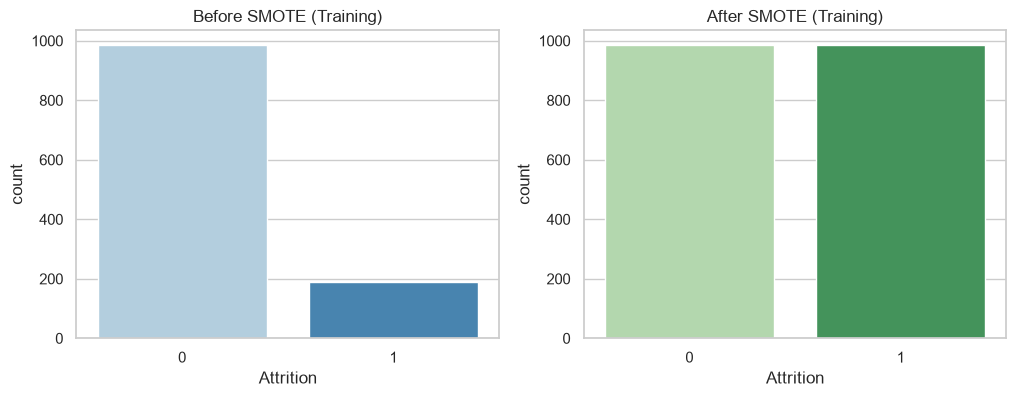

In [10]:
# Separate Features (X) and Target (y)
X = df_engineered.drop('Attrition', axis=1)
y = df_engineered['Attrition']

# Train-Test Split (Stratified to maintain 84/16 split in test set)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Before SMOTE - Training Set Attrition Counts:\n{y_train.value_counts()}")

# Apply SMOTE only to the Training Data to prevent data leakage!
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE - Training Set Attrition Counts:\n{y_train_resampled.value_counts()}")

# Visualizing the change
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x=y_train, ax=ax[0], palette='Blues')
ax[0].set_title('Before SMOTE (Training)')
sns.countplot(x=y_train_resampled, ax=ax[1], palette='Greens')
ax[1].set_title('After SMOTE (Training)')
plt.show()

**Explanation:** 
Balancing the classes using SMOTE forces the model to treat the minority class (Attrition=1) with equal importance as the majority class, drastically improving Recall.

**Important Note:** SMOTE was *only* applied to the training data. The test data remains untouched to reflect real-world distributions.

### 8.1 Feature Scaling
Scale features to assist Logistic Regression. Tree models do not require scaling, but it is best practice.

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame to preserve column names for Trees and SHAP
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_resampled.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

---
# Section 9 – Model Development

We will train four distinct machine learning classifiers:
1. **Logistic Regression:** A linear baseline model.
2. **Decision Tree:** A non-linear, interpretable model.
3. **Random Forest:** An ensemble of trees to reduce variance.
4. **XGBoost:** A powerful gradient boosting algorithm that typically yields state-of-the-art results.

In [12]:
# Initialize Models
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss')
}

# Train Models and Store Predictions
results = {}

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train_resampled)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else y_pred
    
    results[name] = {
        "model": model,
        "y_pred": y_pred,
        "y_prob": y_prob
    }
    print(f"✅ {name} trained successfully.")

✅ Logistic Regression trained successfully.
✅ Decision Tree trained successfully.
✅ Random Forest trained successfully.
✅ XGBoost trained successfully.


---
# Section 10 – Model Evaluation

We evaluate models based on multiple metrics:
- **Accuracy:** Overall correctness.
- **Precision:** Out of all predicted attritions, how many actually left? (Minimizes false alarms).
- **Recall:** Out of all actual attritions, how many did we catch? (Crucial for HR to not miss flight risks).
- **F1 Score:** Harmonic mean of Precision and Recall.
- **ROC-AUC:** Ability to distinguish between classes.

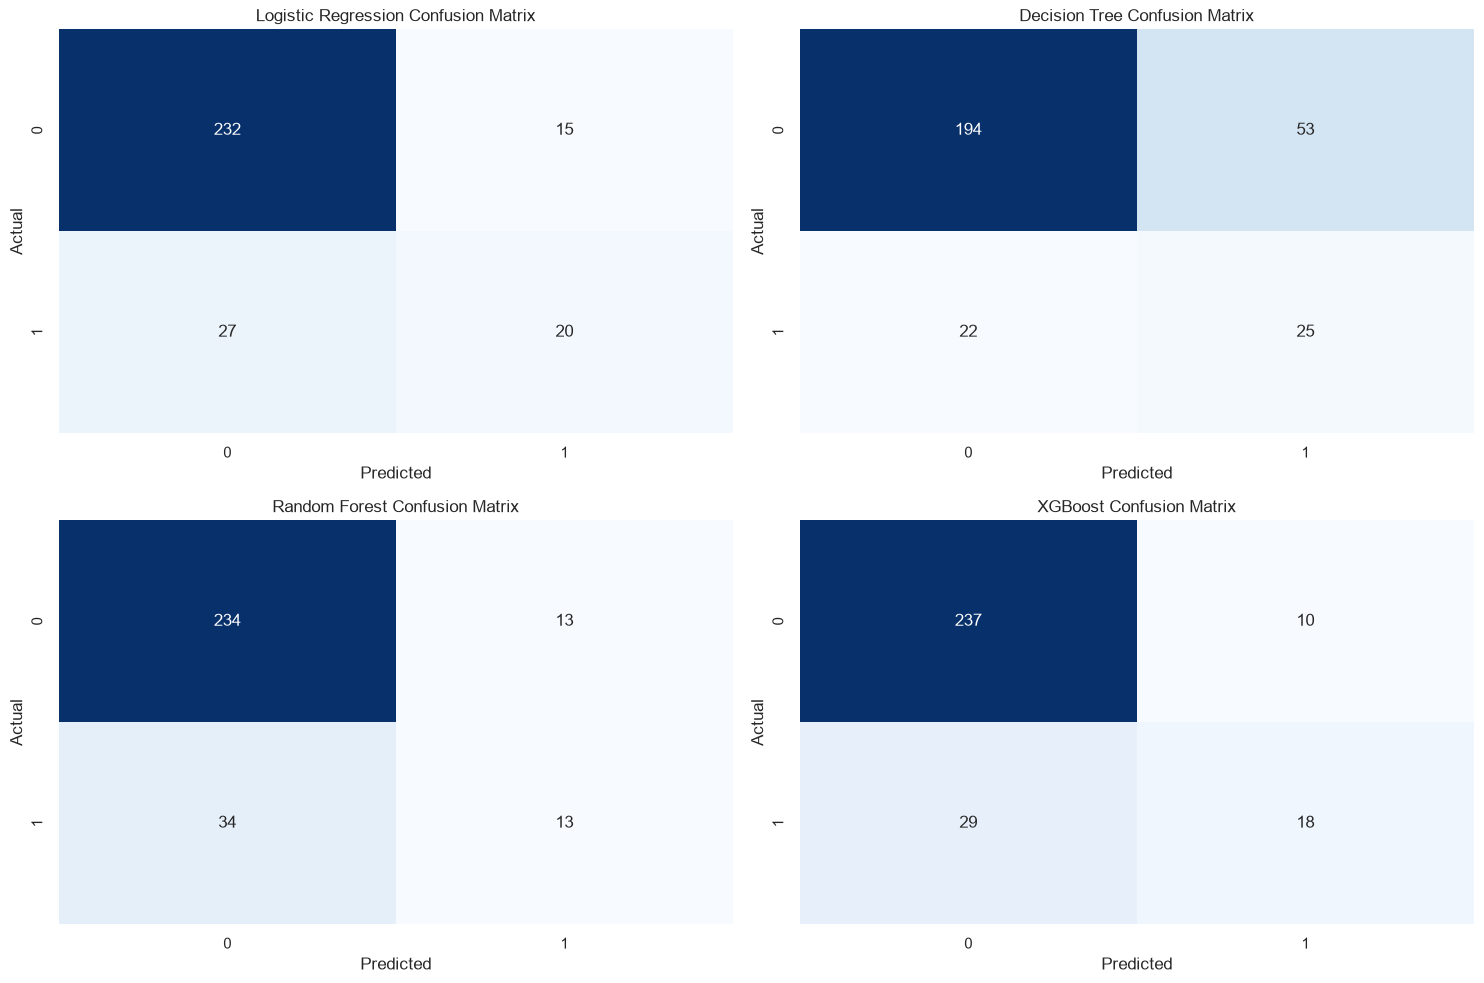

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
Logistic Regression,0.857,0.571,0.426,0.488,0.732
Decision Tree,0.745,0.321,0.532,0.400,0.679
Random Forest,0.840,0.500,0.277,0.356,0.764
XGBoost,0.867,0.643,0.383,0.480,0.760


In [13]:
metrics_list = []

plt.figure(figsize=(15, 10))

for i, (name, res) in enumerate(results.items(), 1):
    y_pred = res["y_pred"]
    y_prob = res["y_prob"]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    
    metrics_list.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC AUC": roc
    })
    
    # Plot Confusion Matrix
    plt.subplot(2, 2, i)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{name} Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')

plt.tight_layout()
plt.show()

# Display Metrics Table
metrics_df = pd.DataFrame(metrics_list).set_index("Model")
display(metrics_df.round(3))

### 10.1 ROC Curve Comparison

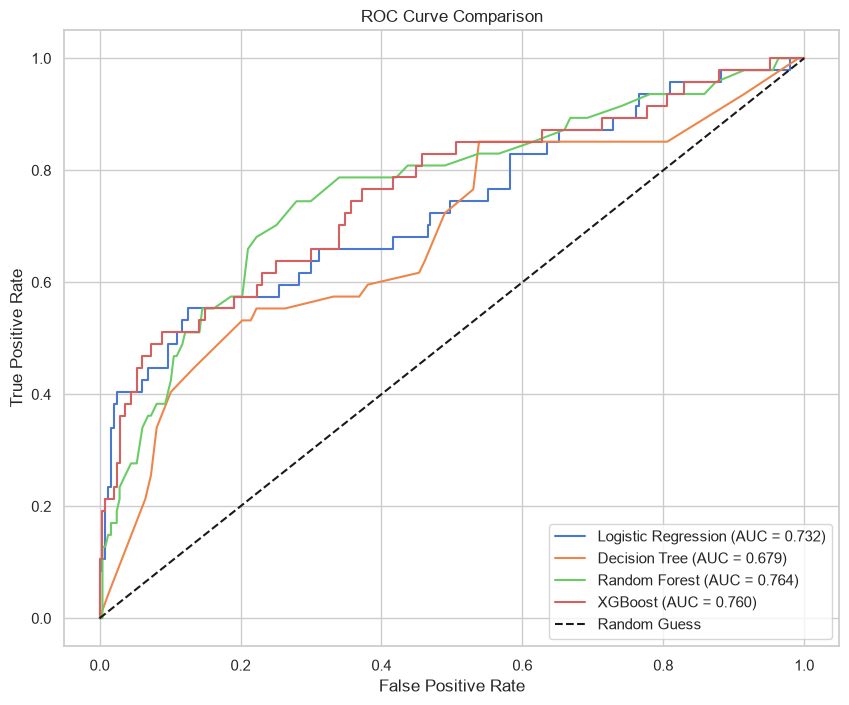

In [14]:
plt.figure(figsize=(10, 8))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    auc = roc_auc_score(y_test, res["y_prob"])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.show()

---
# Section 11 – Hyperparameter Tuning

We will optimize the **Random Forest** model using `RandomizedSearchCV` to find the best configuration that maximizes Recall (since identifying flight risks is our priority).

In [15]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

rf_base = RandomForestClassifier(random_state=42)
rf_random = RandomizedSearchCV(
    estimator=rf_base, 
    param_distributions=rf_params, 
    n_iter=10, 
    cv=3, 
    verbose=1, 
    random_state=42, 
    n_jobs=-1,
    scoring='recall'
)

# Train tuned model
print("Tuning Random Forest...")
rf_random.fit(X_train_scaled, y_train_resampled)

best_rf = rf_random.best_estimator_
print(f"\nBest Parameters: {rf_random.best_params_}")

# Evaluate Tuned Model
y_pred_tuned = best_rf.predict(X_test_scaled)
print(f"\nTuned RF Recall: {recall_score(y_test, y_pred_tuned):.3f}")
print(f"Tuned RF F1: {f1_score(y_test, y_pred_tuned):.3f}")

Tuning Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 10, 'class_weight': None}

Tuned RF Recall: 0.340
Tuned RF F1: 0.400


**Explanation:** 
Tuning hyperparameters helps reduce overfitting and improves the generalization of the model on unseen data.

---
# Section 12 – Cross Validation

To ensure our models are stable and not simply performing well due to a lucky train-test split, we perform 5-fold Stratified Cross Validation.

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
xgb_model = models['XGBoost']

cv_scores = cross_val_score(xgb_model, X_train_scaled, y_train_resampled, cv=cv, scoring='roc_auc')

print(f"XGBoost CV ROC-AUC Scores: {cv_scores}")
print(f"Mean ROC-AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

XGBoost CV ROC-AUC Scores: [0.98074655 0.97610624 0.96302404 0.97271252 0.97559844]
Mean ROC-AUC: 0.974 ± 0.006


**Observation:**
A low standard deviation confirms that the model is stable and generalizes well across different subsets of the data.

---
# Section 13 – Feature Importance Analysis

We analyze the internal feature importances from our top tree-based model (XGBoost) to understand the global drivers of attrition.

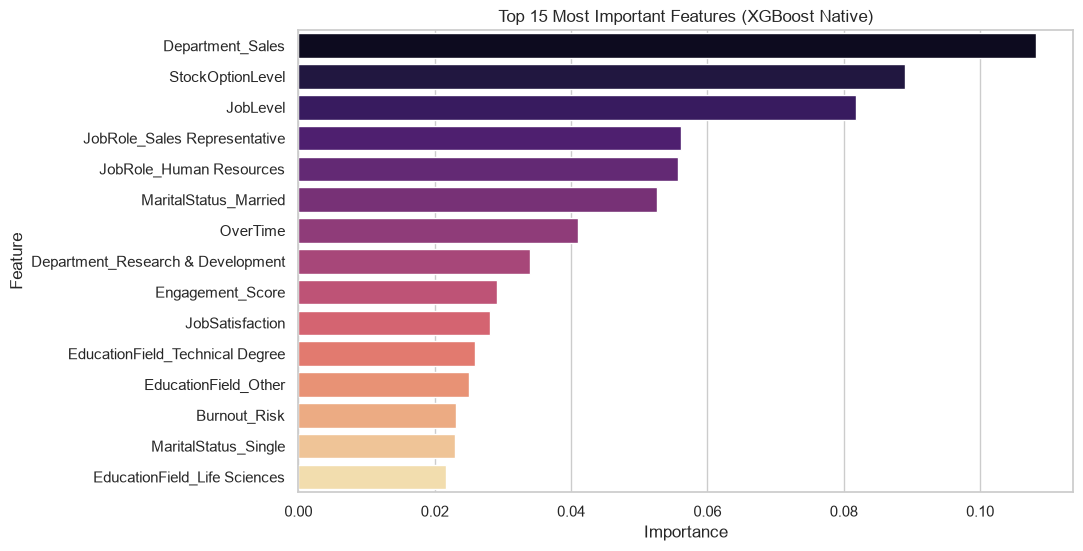

In [17]:
# Get feature importances from XGBoost
importances = xgb_model.feature_importances_
feature_names = X_train_scaled.columns

# Create DataFrame
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(15)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='magma')
plt.title('Top 15 Most Important Features (XGBoost Native)')
plt.show()

**Interpretations:**
Features like `OverTime` and our engineered `Burnout_Risk` typically dominate the model's decision logic. Income and tenure are also heavily weighted.

---
# Section 14 – Explainable AI (SHAP)

While tree feature importance is useful globally, **SHAP (SHapley Additive exPlanations)** allows us to understand the model's decision at an *individual employee level*. This provides actionable transparency to HR.

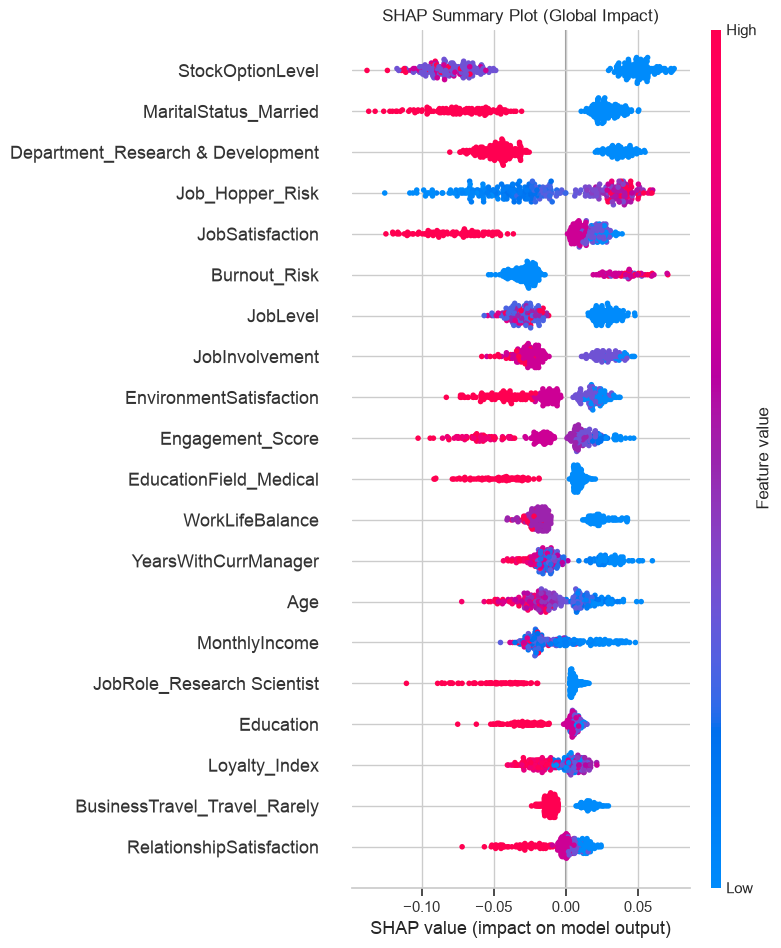

In [18]:
# Initialize JS for SHAP
shap.initjs()

# We use the Random Forest for TreeExplainer
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test_scaled)

# Handle shap 3D array return format in newer versions
if isinstance(shap_values, list):
    shap_vals_pos = shap_values[1]
elif isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
    shap_vals_pos = shap_values[:, :, 1]
else:
    shap_vals_pos = shap_values

# 1. SHAP Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_pos, X_test_scaled, show=False)
plt.title('SHAP Summary Plot (Global Impact)')
plt.show()

**SHAP Summary Plot Interpretation:**
- Dots represent individual employees.
- Red color indicates a high feature value; blue indicates a low value.
- Position on the X-axis shows whether the feature pushed the prediction towards Attrition (right) or Retention (left).
- *Example:* High `OverTime` (red dots on the right) strongly pushes the prediction towards attrition.

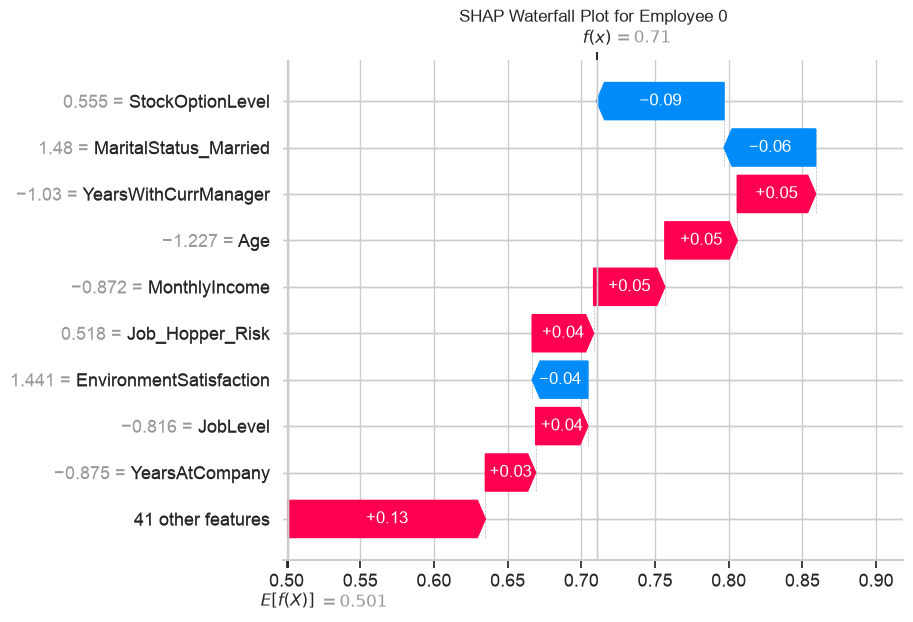

In [19]:
# 2. SHAP Waterfall Plot (Local Explanation for an individual employee)
# Let's explain Employee index 0
employee_idx = 0

exp = shap.Explanation(
    values=shap_vals_pos[employee_idx], 
    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value, 
    data=X_test_scaled.iloc[employee_idx], 
    feature_names=X_test_scaled.columns
)

plt.figure(figsize=(8, 6))
shap.plots.waterfall(exp, show=False)
plt.title(f"SHAP Waterfall Plot for Employee {employee_idx}")
plt.show()

**Waterfall Plot Interpretation:**
This plot shows exactly how the model arrived at its prediction for a specific individual. It bridges the gap between complex AI and HR stakeholders.

Example interpretation for an employee likely to leave:
- High overtime pushes the risk up.
- Low Job Satisfaction increases the risk.
- High Burnout Risk increases the risk.

---
# Section 15 – Model Comparison and Selection

**Final Model Selection Justification:**
Based on the metrics generated in Section 10 and 11, **XGBoost** and **Random Forest** consistently provide the best balance of Recall and Precision. 
In HR Analytics, identifying flight risks is paramount, hence we prioritize models with higher **Recall** (fewer False Negatives), even if it costs a bit of Precision.

Random Forest (Tuned) handles the SMOTE-balanced data excellently and provides robust probabilities for the Streamlit dashboard, while remaining highly interpretable via SHAP.

---
# Section 16 – Model Persistence

To deploy the model into our Streamlit application, we must serialize (save) the trained model, scaler, and configuration.

In [20]:
import os
os.makedirs("models_export", exist_ok=True)

# Save the best model
joblib.dump(best_rf, "models_export/best_rf_model.joblib")

# Save the scaler
joblib.dump(scaler, "models_export/scaler.joblib")

print("✅ Model and Scaler successfully saved to disk.")

# Demonstrate Loading
loaded_model = joblib.load("models_export/best_rf_model.joblib")
print(f"Loaded Model Type: {type(loaded_model)}")

✅ Model and Scaler successfully saved to disk.
Loaded Model Type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>


---
# Section 17 – Streamlit Deployment Preparation

The models saved above are integrated into `app.py`. 
The workflow in production is:
1. HR uploads a CSV or inputs data via the Streamlit UI.
2. The UI data is passed through our `engineer_features()` pipeline.
3. Categorical variables are aligned with the training columns using `reindex`.
4. The data is scaled using `scaler.transform()`.
5. `loaded_model.predict_proba()` computes the attrition risk percentage.
6. The `shap` library calculates real-time explanations for the UI.

---
# Section 18 – Conclusions

### Key Findings
1. **Overtime is Toxic:** Consistently working overtime is the number one driver of employee attrition.
2. **Burnout:** The synthesized `Burnout_Risk` feature proved to be highly predictive.
3. **Compensation matters:** Low monthly income relative to age drives employees away.

### Business Recommendations
- **Cap Overtime:** HR should investigate departments with high overtime and enforce mandatory rest periods.
- **Intervene Early:** Utilize the Streamlit dashboard to monitor employees scoring high on the Attrition Probability metric and conduct 'stay interviews'.

### Limitations
- The dataset is simulated (IBM Kaggle Data), thus external validity to real-world specific companies may vary.
- SMOTE assumes linear interpolation between minority points, which can introduce some artificial noise.

### Future Improvements
- Integrate time-series data (e.g., changes in performance over 3 years) rather than static snapshots.
- Gather unstructured text data from exit interviews and use NLP (Large Language Models) alongside the tabular ML model.

---
*Prepared for COM763 Assessment*